# 데이터 분석 및 결측+중복 정제

1. 원본 데이터 전체 분석
2. 결측치 확인 및 처리
3. 중복 데이터 제거
4. 정제 데이터 재분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
import matplotlib.font_manager as fm
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

## 수집 데이터 종합 : "original_data.csv"

In [2]:
ORIGINAL_FILE_NAME = "original_data.csv"

if not os.path.exists(ORIGINAL_FILE_NAME) :
    try :
        df1 = pd.read_csv("steam_user_games_1.csv")
        df2 = pd.read_csv("steam_user_games_2.csv")
        df3 = pd.read_csv("steam_user_games_3.csv")
        df4 = pd.read_csv("steam_user_games_4_5_6.csv")

        merged = pd.concat([df1, df2, df3, df4], ignore_index=True)
        merged.to_csv("original_data.csv", index=False)
        
        print(ORIGINAL_FILE_NAME, "파일 생성 완료")
        
    except Exception as e :
        print(ORIGINAL_FILE_NAME, "파일 생성 실패")
else :
    print(ORIGINAL_FILE_NAME, "파일 확인 완료")

df = pd.read_csv(ORIGINAL_FILE_NAME)

original_data.csv 파일 확인 완료


## 1. 원본 데이터 전체 분석

In [4]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Unique steamid (유저 수): {df['steamid'].nunique():,}")
print(f"Unique appid (게임 수): {df['appid'].nunique():,}")
df.dtypes

Shape: 27,000 rows x 16 cols
Unique steamid (유저 수): 878
Unique appid (게임 수): 3,564


steamid                    int64
appid                      int64
game_name                 object
playtime_hours           float64
recent_playtime_hours    float64
genre                     object
tags                      object
steam_categories          object
total_reviews              int64
positive_reviews           int64
negative_reviews           int64
rating_by_reviews         object
recommendations            int64
metacritic                object
release_date              object
price(원)                  object
dtype: object

### 결측치 현황 확인
일부 컬럼은 결측이 `NaN`이 아니라 `'Unknown'` 문자열로 표시되어 있어, 두 종류를 모두 확인함

In [6]:
# 진짜 NaN
na_real = df.isna().sum()
na_real = na_real[na_real > 0]
print("[진짜 NaN]")
print(na_real)

# 'Unknown' 문자열로 위장된 결측치
unknown_candidates = ['genre', 'tags', 'steam_categories', 'rating_by_reviews',
                       'metacritic', 'release_date', 'price(원)']
unknown_counts = {}
for col in unknown_candidates:
    cnt = (df[col].astype(str).str.strip() == 'Unknown').sum()
    if cnt > 0:
        unknown_counts[col] = cnt

unknown_series = pd.Series(unknown_counts).sort_values(ascending=False)
print("\n['Unknown' 위장 결측치]")
print(unknown_series)

[진짜 NaN]
release_date    74
dtype: int64

['Unknown' 위장 결측치]
metacritic           13800
tags                  3804
price(원)              3379
steam_categories      2208
genre                 2199
release_date          2117
rating_by_reviews       35
dtype: int64


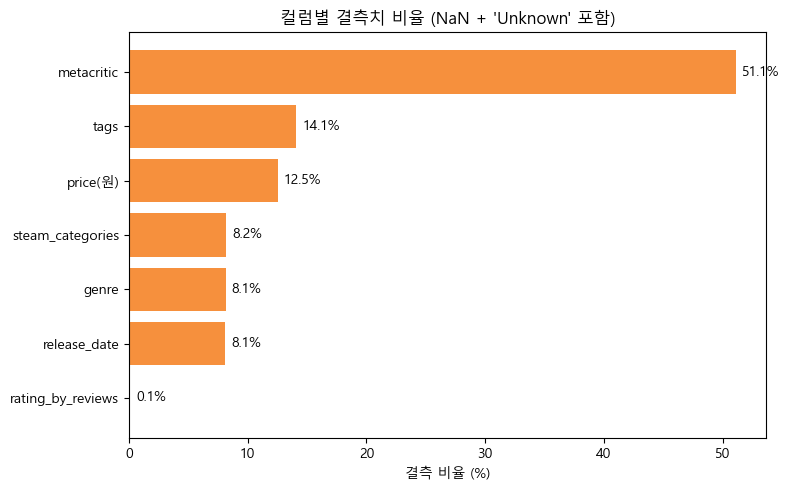

In [7]:
# 결측치 시각화 (Unknown 포함 전체 결측 비율)
total_missing = unknown_series.add(na_real, fill_value=0).sort_values(ascending=False)
missing_pct = (total_missing / len(df) * 100)

plt.figure(figsize=(8,5))
bars = plt.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='#F6903D')
plt.xlabel('결측 비율 (%)')
plt.title('컬럼별 결측치 비율 (NaN + \'Unknown\' 포함)')
for bar, val in zip(bars, missing_pct.values[::-1]):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.show()

## 2. 결측치 처리

| 컬럼 | 결측 비율 | 처리 방식 |
|---|---|---|
| `rating_by_reviews` | 0.1% | 중앙값 대치 |
| `price(원)` | 12.5% | 중앙값 대치 |
| `metacritic` | 51.1% | 대치하지 않고 NaN 유지 + `has_metacritic` 플래그 추가 (과반 결측이라 임의 대치 시 왜곡 위험) |
| `release_date` | 8.2% | NaT 유지 (추후 `release_year` 파생 시 결측 반영) |
| `genre`/`tags`/`steam_categories` | 8~14% | 이미 `'Unknown'` 카테고리로 존재 → 별도 처리 불필요 |

In [8]:
# 'Unknown' -> 실제 NaN 변환 (수치/날짜 컬럼)
for col in ['rating_by_reviews', 'metacritic', 'price(원)']:
    df[col] = pd.to_numeric(df[col].replace('Unknown', np.nan), errors='coerce')

df['release_date'] = pd.to_datetime(
    df['release_date'].replace('Unknown', np.nan), errors='coerce', format='mixed'
)

before_missing = df[['rating_by_reviews','metacritic','price(원)','release_date']].isna().sum()
before_missing

rating_by_reviews       35
metacritic           13800
price(원)              3379
release_date          2227
dtype: int64

In [9]:
# 컬럼별 결측치 처리
median_rating = df['rating_by_reviews'].median()
df['rating_by_reviews'] = df['rating_by_reviews'].fillna(median_rating)
print(f"[rating_by_reviews] 중앙값({median_rating})으로 대치")

median_price = df['price(원)'].median()
df['price(원)'] = df['price(원)'].fillna(median_price)
print(f"[price(원)] 중앙값({median_price:,.0f}원)으로 대치")

df['has_metacritic'] = df['metacritic'].notna().astype(int)
print("[metacritic] NaN 유지 + has_metacritic 플래그 컬럼 추가")

print(f"[release_date] NaT 유지 (결측 {df['release_date'].isna().sum():,}건)")

[rating_by_reviews] 중앙값(90.36)으로 대치
[price(원)] 중앙값(16,500원)으로 대치
[metacritic] NaN 유지 + has_metacritic 플래그 컬럼 추가
[release_date] NaT 유지 (결측 2,227건)


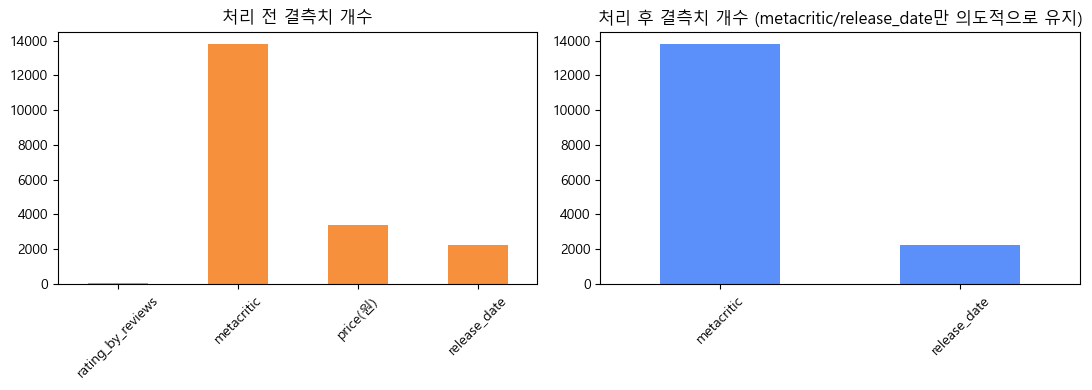

In [10]:
after_missing = df.isna().sum()
after_missing = after_missing[after_missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(11,4))

before_missing.plot(kind='bar', ax=axes[0], color='#F6903D')
axes[0].set_title('처리 전 결측치 개수')
axes[0].tick_params(axis='x', rotation=45)

after_missing.plot(kind='bar', ax=axes[1], color='#5B8FF9')
axes[1].set_title('처리 후 결측치 개수 (metacritic/release_date만 의도적으로 유지)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. 중복 데이터 제거

두 종류의 중복을 발견

1. **완전 중복행**: 모든 컬럼 값이 동일한 행
2. **(유저, 게임) 쌍은 같지만 일부 값이 미세하게 다른 행**: 재수집 시점 차이로 추정

In [11]:
rows_before = len(df)

full_dup_count = df.duplicated().sum()
print(f"완전 중복 행: {full_dup_count:,}건")
df = df.drop_duplicates()
rows_after_full = len(df)

dup_key_mask = df.duplicated(subset=['steamid','appid'], keep=False)
remaining_groups = df[dup_key_mask].groupby(['steamid','appid']).ngroups
print(f"(유저,게임) 쌍 기준 잔여 중복 그룹: {remaining_groups:,}개")

df = df.drop_duplicates(subset=['steamid','appid'], keep='first')
rows_after_key = len(df)

print(f"\n행 수 변화: {rows_before:,} -> {rows_after_full:,} (완전중복 제거) -> {rows_after_key:,} ((유저,게임) 중복 제거)")

완전 중복 행: 321건
(유저,게임) 쌍 기준 잔여 중복 그룹: 319개

행 수 변화: 27,000 -> 26,679 (완전중복 제거) -> 26,340 ((유저,게임) 중복 제거)


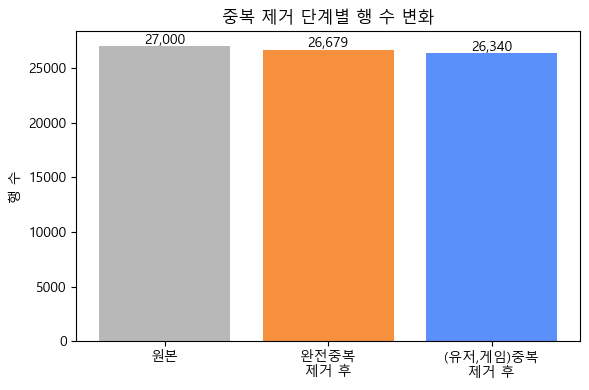

In [12]:
stage_labels = ['원본', '완전중복\n제거 후', '(유저,게임)중복\n제거 후']
stage_values = [rows_before, rows_after_full, rows_after_key]

plt.figure(figsize=(6,4))
bars = plt.bar(stage_labels, stage_values, color=['#B8B8B8', '#F6903D', '#5B8FF9'])
plt.title('중복 제거 단계별 행 수 변화')
plt.ylabel('행 수')
for bar, val in zip(bars, stage_values):
    plt.text(bar.get_x()+bar.get_width()/2, val + 200, f'{val:,}', ha='center')
plt.tight_layout()
plt.show()

## 4. 정제된 데이터 재분석

In [13]:
print(f"[Shape] {df.shape[0]:,} rows x {df.shape[1]} cols "
      f"(원본 대비 {rows_before-len(df):,}행 감소, {(rows_before-len(df))/rows_before*100:.1f}%)")
print(f"[Unique steamid] {df['steamid'].nunique():,}")
print(f"[Unique appid] {df['appid'].nunique():,}")

games_per_user_after = df.groupby('steamid').size()
games_per_user_after.describe()

[Shape] 26,340 rows x 17 cols (원본 대비 660행 감소, 2.4%)
[Unique steamid] 878
[Unique appid] 3,564


count    878.0
mean      30.0
std        0.0
min       30.0
25%       30.0
50%       30.0
75%       30.0
max       30.0
dtype: float64

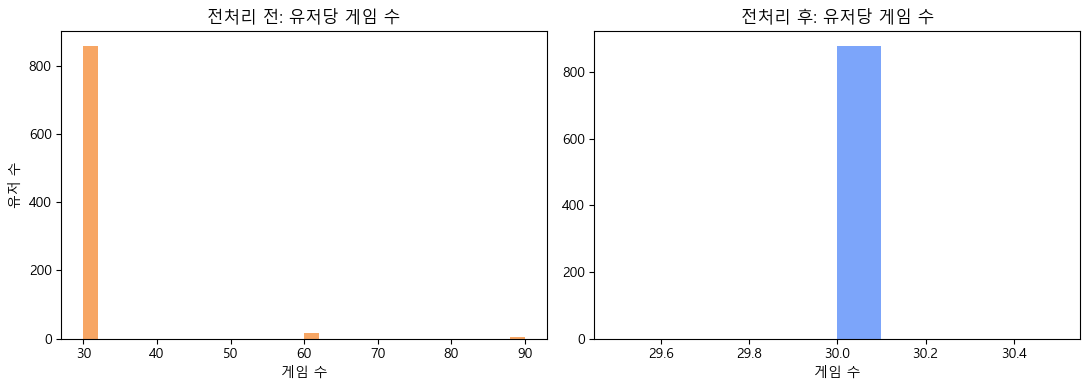

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

axes[0].hist(games_per_user, bins=30, color='#F6903D', alpha=0.8)
axes[0].set_title('전처리 전: 유저당 게임 수')
axes[0].set_xlabel('게임 수')
axes[0].set_ylabel('유저 수')

axes[1].hist(games_per_user_after, bins=10, color='#5B8FF9', alpha=0.8)
axes[1].set_title('전처리 후: 유저당 게임 수')
axes[1].set_xlabel('게임 수')

plt.tight_layout()
plt.show()

### 결과 저장

In [15]:
df.to_csv('cleaned_data.csv', index=False)
print(f"저장 완료: {df.shape[0]:,} rows x {df.shape[1]} cols")

저장 완료: 26,340 rows x 17 cols
